<a href="https://colab.research.google.com/github/GuilhermeMulazzani/cgvis-lab03-visualizacao/blob/main/Lab03_visualizacao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

A buscar dados do SDSS DR17...
Dados filtrados! A gerar o Gráfico de Densidade...


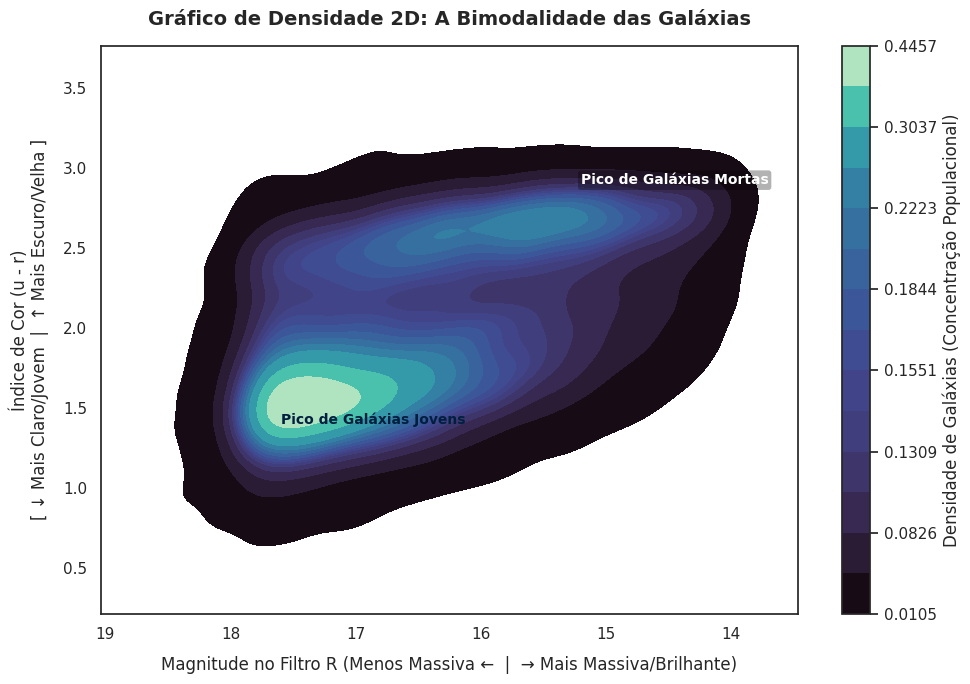

In [1]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO

print("A buscar dados do SDSS DR17...")

query = """
SELECT TOP 30000
   p.u, p.r, (p.u - p.r) as color_ur,
   p.petroMag_r as magnitude
FROM Galaxy AS p
JOIN SpecObj AS s ON s.bestobjid = p.objid
WHERE p.u BETWEEN 13 AND 22
  AND p.r BETWEEN 13 AND 22
  AND s.z BETWEEN 0.02 AND 0.05
"""

url = "http://skyserver.sdss.org/dr17/SkyServerWS/SearchTools/SqlSearch"
response = requests.get(url, params={'cmd': query, 'format': 'csv'})
df = pd.read_csv(StringIO(response.text), comment='#').dropna()

# Limpeza prévia de outliers para alinhar perfeitamente os eixos com a legenda
df = df[df['color_ur'].between(0.5, 3.5)]
df = df[df['magnitude'].between(14, 18.5)]

print("Dados filtrados! A gerar o Gráfico de Densidade...")

plt.figure(figsize=(10, 7))
sns.set_theme(style="white")

# cor mostra a CONCENTRAÇÃO de galáxias
kde = sns.kdeplot(
    data=df, x='magnitude', y='color_ur',
    fill=True, thresh=0.02, levels=15, cmap="mako", cbar=True,
    cbar_kws={'label': 'Densidade de Galáxias (Concentração Populacional)'}
)

# Mantém o padrão científico astronômico
plt.gca().invert_xaxis()

plt.title("Gráfico de Densidade 2D: A Bimodalidade das Galáxias", fontsize=14, pad=15, weight='bold')
plt.xlabel("Magnitude no Filtro R (Menos Massiva ←  |  → Mais Massiva/Brilhante)", fontsize=12, labelpad=10)
plt.ylabel("Índice de Cor (u - r)\n[ ↓ Mais Claro/Jovem  |  ↑ Mais Escuro/Velha ]", fontsize=12, labelpad=10)

# 3. Correção de Contraste e Leitura (Usando cores claras ou caixas de fundo)
# Para o fundo escuro, usamos texto branco (color='white')
plt.text(15.2, 2.90, 'Pico de Galáxias Mortas',
         fontsize=10, color='white', weight='bold',
         bbox=dict(facecolor='black', alpha=0.3, edgecolor='none', boxstyle='round,pad=0.2'))

# Para o fundo claro (verde), usamos texto bem escuro
plt.text(17.6, 1.40, 'Pico de Galáxias Jovens',
         fontsize=10, color='#001f3f', weight='bold')

plt.tight_layout()
plt.show()